# C3.3 – Segmentation clients

> Ce notebook a pour objectif de valider la compétence **C3.3 - Segmentation et réduction de base de données**.

**Contexte :**

La direction marketing d'une enseigne de centre commercial souhaite mieux comprendre les profils clients afin :

- d'adapter les campagnes promotionnelles,
- d'identifier les clients à fort potentiel,
- d'optimiser les offres personnalisées,
- de mettre en place des stratégies de fidélisation ciblées.

**Jeu de données :**

L'analyse repose sur le jeu de données *Mall Customers Dataset*. Il contient des informations tabulaires sur 200 clients.

| Colonne | Description |
| :- | :- |
| CustomerID | identifiant unique |
| Gender | genre du client |
| Age | âge du client |
| Annual Income (k$) | revenu annuel du client en milliers de dollars |
| Spending Score (1-100) | score de dépense attribué par le centre commercial (indicateur interne basé sur le comportement d’achat) |

Le jeu de données est téléchargeable sur Kaggle à partir du lien suivant : <https://www.kaggle.com/datasets/shwetabh123/mall-customers>.

**Objectif général :**

Mettre en oeuvre une segmentation non supervisée des clients afin de proposer une analyse stratégique exploitable par le service marketing.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings("ignore")

SEED = 73
np.random.seed(SEED)

ALPHA = 0.05

In [2]:
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

## Analyse exploratoire

In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print(f"Le jeu de données comprend {df.shape[0]} lignes et {df.shape[1]} colonnes.")
print(f"Les colonnes du jeu de données sont : {df.columns.to_list()}")

Le jeu de données comprend 200 lignes et 5 colonnes.
Les colonnes du jeu de données sont : ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


La colonne `CustomerID` n'est pas pertinente pour la segmentation clients car il s'agit d'un identifiant unique. On s'intéresse alors aux quatre autres variables.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Aucune valeur manquante.

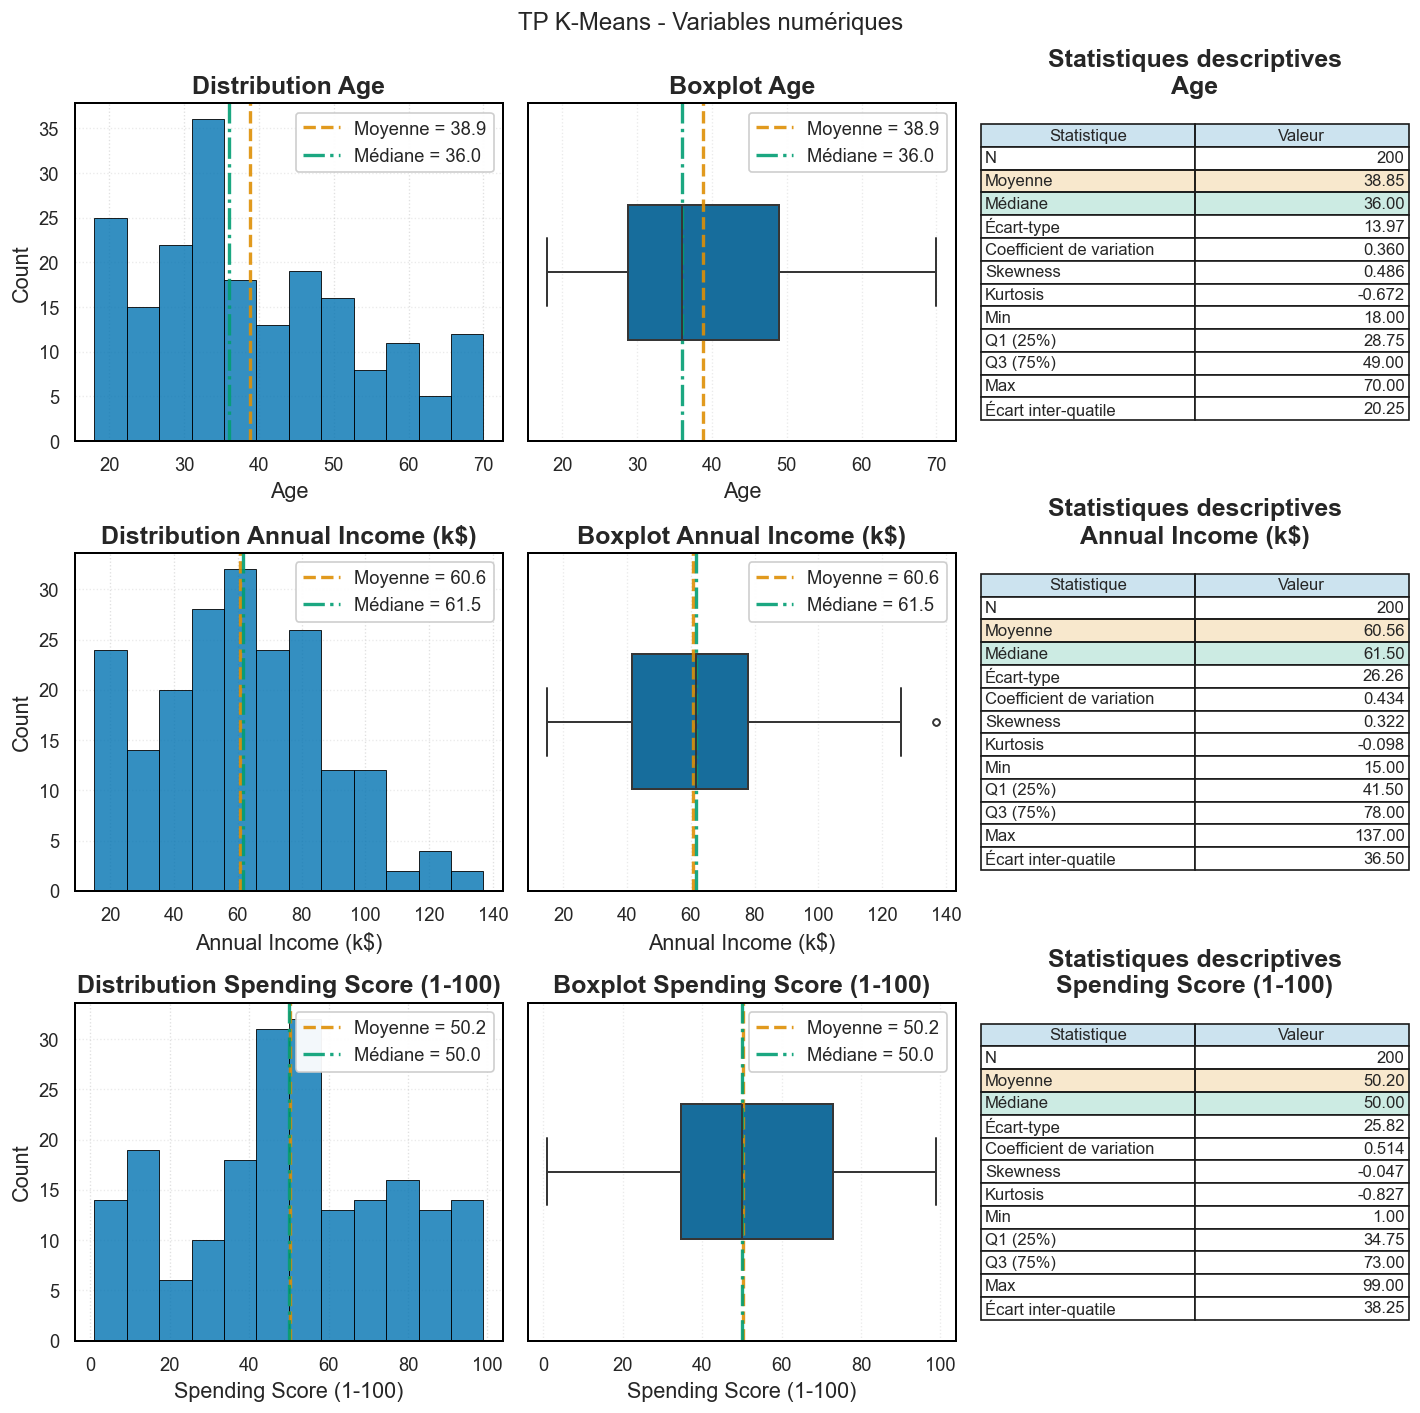

In [6]:
def create_histplot(ax, df, column):
    values = df[column].dropna()

    sns.histplot(
        x=values,
        bins=12,
        color=COLORBLIND_PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = values.mean()
    median_column = values.median()

    ax.axvline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_boxplot(ax, df, column):
    values = df[column].dropna()

    sns.boxplot(
        x=values,
        ax=ax,
        color=COLORBLIND_PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = values.mean()
    median_val = values.median()

    ax.axvline(
        mean_val,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_stats_panel(ax, df, column):
    values = df[column].dropna()

    mean_val = values.mean()
    std_val = values.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = values.skew()
    kurt = values.kurtosis()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{values.median():.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{values.min():.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{values.max():.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(COLORBLIND_PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(COLORBLIND_PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(COLORBLIND_PALETTE[2] + (0.2,))

    ax.set_axis_off()


fig, axes = plt.subplots(3, 3, figsize=(12, 12))

fig.suptitle("TP K-Means - Variables numériques")

num_var = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

for k in range(3):
    ax1 = axes[k, 0]
    create_histplot(ax=ax1, df=df, column=num_var[k])
    ax1.set_title(f"Distribution {num_var[k]}")

    ax2 = axes[k, 1]
    create_boxplot(ax2, df, num_var[k])
    ax2.set_title(f"Boxplot {num_var[k]}")

    ax3 = axes[k, 2]
    create_stats_panel(ax3, df, num_var[k])
    ax3.set_title(f"Statistiques descriptives\n{num_var[k]}")

fig.tight_layout()
plt.show()

Observations :
- Variable `Age` :
  - La distribution est homogène et aplatie, elle présente une légère asymétrie et une variabilité relative modérée.
  - Aucun outlier n'est détecté avec la méthode de Turkey.
- Variable `Annual income` :
  - La distribution est quasi symétrique, elle présente une homogénéité moyenne, une forme quasi normale et une variabilité relative forte.
  - Un outlier est détecté avec la méthode de Turkey.
- Variable `Spending Score` :
  - La distribution est symétrique, hétérogène et très aplatie, elle présente une variabilité relative forte.
  - Aucun outlier n'est détecté avec la méthode de Turkey.

Conclusions :
- Les variables `Age`, `Annual income` et `Spending Score` présentent une variabilité suffisante pour une segmentation.
- L'absence d'outlier est cohérente avec les hypothèses de K-Means.

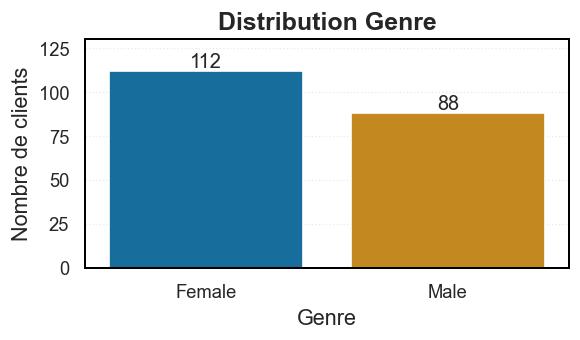

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(5, 3))

churn = df["Genre"].value_counts()

barplot = sns.barplot(
    x=churn.index,
    y=churn.values,
    palette="colorblind",
    hue=churn.index,
    legend=False,
    ax=axes,
)

for container in barplot.containers:
    barplot.bar_label(container)

axes.grid(axis="y", linestyle=":", alpha=0.4)
axes.set_title("Distribution Genre")
axes.set_xlabel("Genre")
axes.set_ylabel("Nombre de clients")
axes.set_ylim((0,130))

plt.tight_layout()
plt.show()

In [8]:
print(
    f"Proportion de 'Female' dans la variable Genre : "
    f"{churn.loc['Female'] / churn.sum() * 100:.2f}%"
)
print(
    f"Proportion de 'Male' dans la variable Genre : "
    f"{churn.loc['Male'] / churn.sum() * 100:.2f}%"
)

Proportion de 'Female' dans la variable Genre : 56.00%
Proportion de 'Male' dans la variable Genre : 44.00%


Observation :
- Distribution de la variable Genre modérément déséquilibrée.

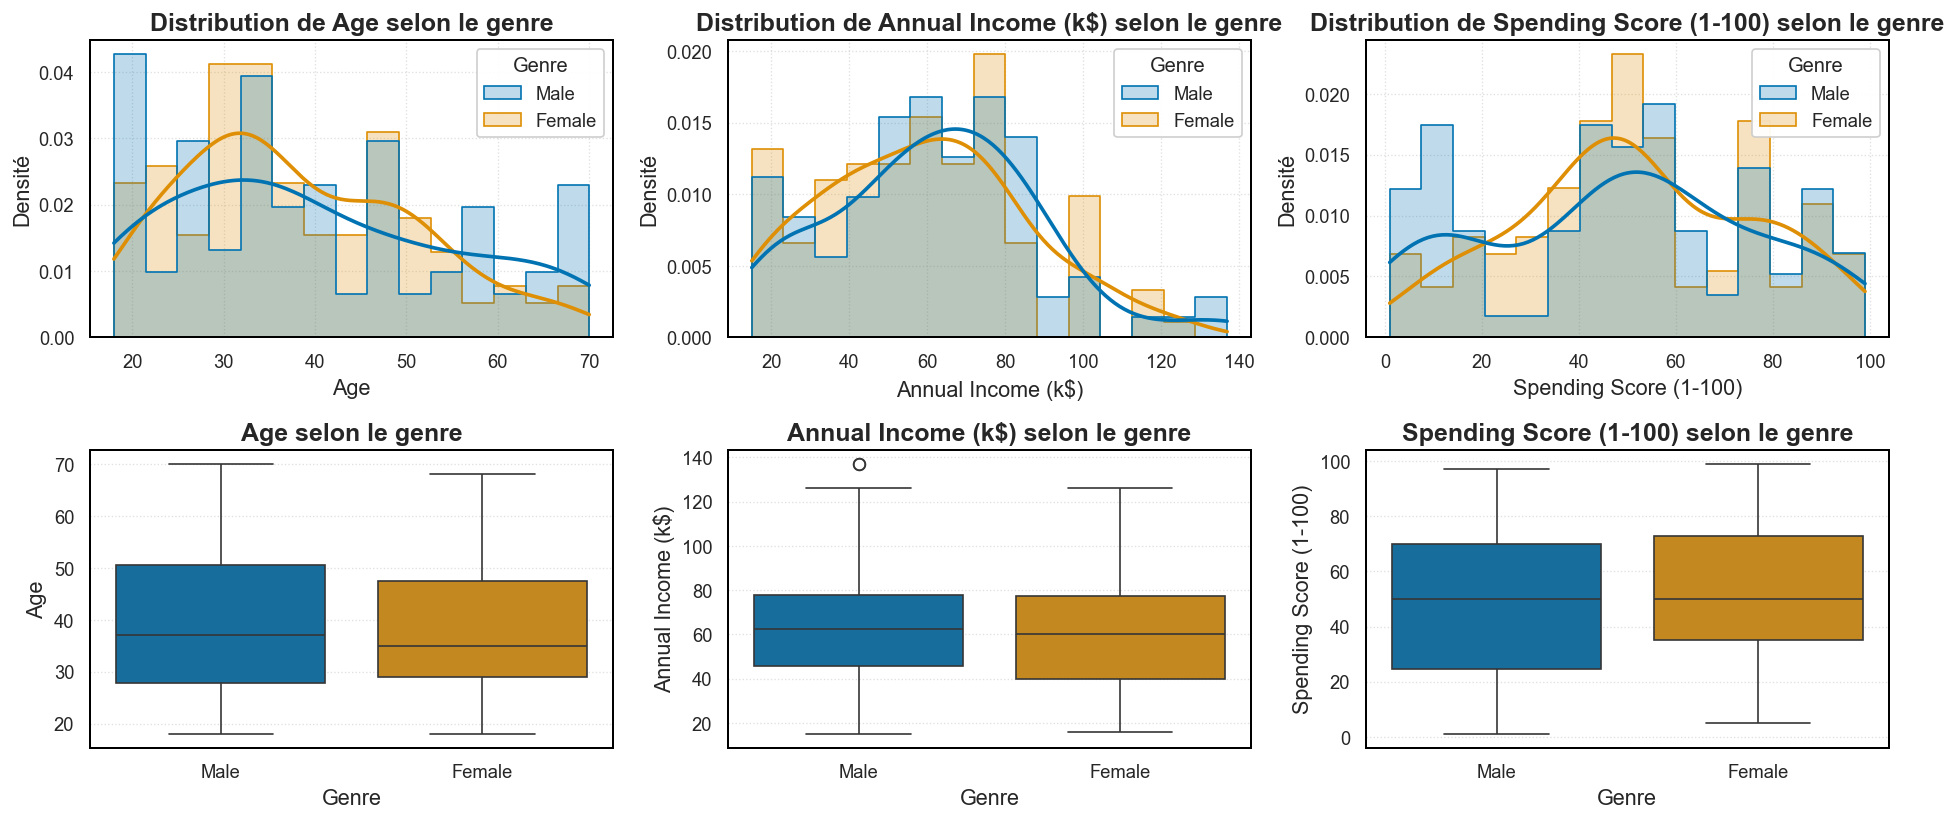

In [9]:
variables = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()
for ax, variable in zip(axes[:3], variables, strict=False):
    sns.histplot(
        data=df,
        x=variable,
        hue="Genre",
        kde=True, bins=15,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(f"Distribution de {variable} selon le genre")
    ax.set_xlabel(variable)
    ax.set_ylabel("Densité")

for ax, variable in zip(axes[3:], variables, strict=False):
    sns.boxplot(
        data=df,
        x="Genre",
        y=variable,
        hue="Genre",
        ax=ax,
    )
    ax.set_title(f"{variable} selon le genre")
    ax.set_xlabel("Genre")
    ax.set_ylabel(variable)

plt.tight_layout()
plt.show()

Observation :
- Il ne semble pas y avoir de différence significative entre les groupes "Male" et "Female" pour les variables `Age`, `Annual Income (k$)` et `Spending Score (1-100)`.

In [10]:
# Séparation des groupes
female = df[df["Genre"] == "Female"]
male = df[df["Genre"] == "Male"]

def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    # Variances
    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)
    # Écart-type poolé
    pooled_std = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

def interpret_cohens_d(d):
    magnitude = abs(d)
    if magnitude < 0.2:
        return "Négligeable"
    elif magnitude < 0.5:
        return "Faible"
    elif magnitude < 0.8:
        return "Moyenne"
    else:
        return "Forte"

# Tests statistiques
results = []
n_tests = len(variables)
for variable in variables:
    # Suppression des valeurs manquantes
    x = female[variable].dropna()
    y = male[variable].dropna()

    # Welch t-test
    t_stat, p_ttest = stats.ttest_ind(x, y, equal_var=False)
    p_ttest_bongerroni = np.minimum(p_ttest * n_tests, 1)

    # Mann-Whitney U
    u_stat, p_mann = stats.mannwhitneyu(x, y, alternative="two-sided")
    p_mann_bongerroni = np.minimum(p_ttest * n_tests, 1)

    # Moyennes et médianes
    mean_female = x.mean()
    mean_male = y.mean()

    median_female = x.median()
    median_male = y.median()

    # Cohen's d
    d = cohens_d(x, y)
    d_interpretation = interpret_cohens_d(d)

    results.append({
        "Variable": variable,
        "Moyenne Female": mean_female,
        "Moyenne Male": mean_male,
        "Médiane Female": median_female,
        "Médiane Male": median_male,
        "p-value Welch": p_ttest,
        "p-value Mann-Whitney": p_mann,
        "p-value Welch Bonferroni": p_ttest_bongerroni,
        "p-value Mann-Whitney Bonferroni": p_mann_bongerroni,
        "Cohen's d": d,
        "Effet Cohen": d_interpretation,
    })

# Tableau des résultats
results_df = pd.DataFrame(results)

print("=== RÉSULTATS DES TESTS ===")
print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# Interprétation automatique
print()
print("=== INTERPRÉTATION ===")

for _, row in results_df.iterrows():
    variable = row["Variable"]
    p_ttest = row["p-value Welch Bonferroni"]
    p_mann = row["p-value Mann-Whitney Bonferroni"]

    print(f"Variable {variable} :")
    if p_ttest < ALPHA:
        print(
            "  Welch t-test : différence significative "
        )
    else:
        print(
            "  Welch t-test : pas de différence significative "
        )

    if p_mann < ALPHA:
        print(
            "  Mann-Whitney : différence significative "
        )
    else:
        print(
            "  Mann-Whitney : pas de différence significative "
        )

=== RÉSULTATS DES TESTS ===
              Variable  Moyenne Female  Moyenne Male  Médiane Female  Médiane Male  p-value Welch  p-value Mann-Whitney  p-value Welch Bonferroni  p-value Mann-Whitney Bonferroni  Cohen's d Effet Cohen
                   Age         38.0982       39.8068         35.0000       37.0000         0.4036                0.6242                    1.0000                           1.0000    -0.1222 Négligeable
    Annual Income (k$)         59.2500       62.2273         60.0000       62.5000         0.4289                0.4144                    1.0000                           1.0000    -0.1133 Négligeable
Spending Score (1-100)         51.5268       48.5114         50.0000       50.0000         0.4220                0.5713                    1.0000                           1.0000     0.1167 Négligeable

=== INTERPRÉTATION ===
Variable Age :
  Welch t-test : pas de différence significative 
  Mann-Whitney : pas de différence significative 
Variable Annual Income (k

Les tests statistiques ne mettent pas en évidence de différence significative entre les hommes et les femmes concernant l'âge, le revenu annuel et le score de dépense. Le genre ne semble donc pas constituer un facteur discriminant majeur pour ces caractéristiques dans l'échantillon étudié. Il est ainsi pertinent de ne pas l'utiliser comme variable principale de clustering.

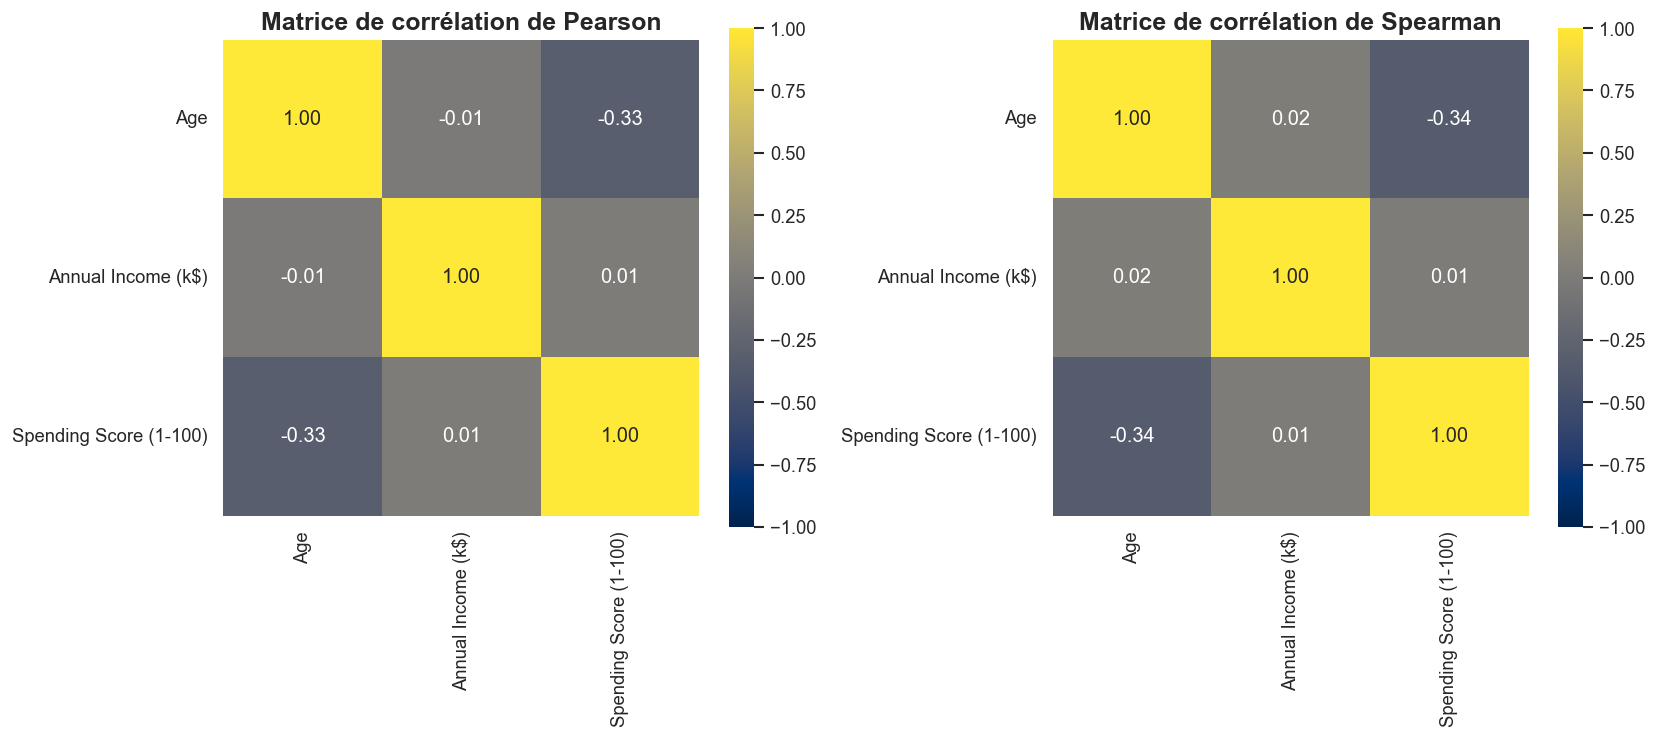

In [11]:
df_corr = df[variables].copy()

corr_pearson = df_corr.corr(method="pearson")
corr_spearman = df_corr.corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax1,
)
ax1.set_title("Matrice de corrélation de Pearson")

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax2,
)
ax2.set_title("Matrice de corrélation de Spearman")

plt.tight_layout()
plt.show()

Observation :
- Corrélation modérée entre les variables `Age` et `Spending Score (1-100)`.

Hypothèse :
- Plus le client est agé, moins son spending score semble élevé en moyenne.

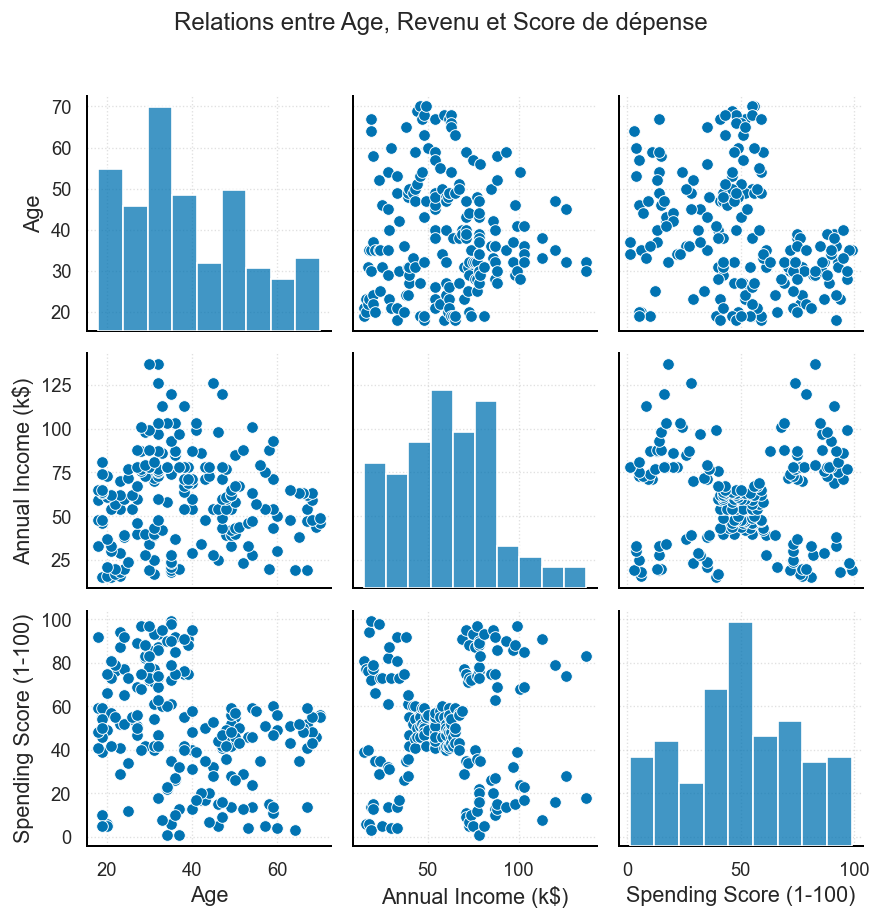

In [12]:
sns.pairplot(
    df_corr,
    diag_kind="hist"
)

plt.suptitle(
    "Relations entre Age, Revenu et Score de dépense",
    y=1.02
)
plt.tight_layout()
plt.show()

Observation :
- Visuellement, les pairplots suggèrent une certaine segmentation des clients, notamment pour les relations entre le score de dépense et l’âge, ainsi qu’entre le score de dépense et le revenu annuel.

## Préparation des données

In [13]:
cat_var = [
    # "Genre",
]
num_vars = [
    # "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
]

X = df[cat_var + num_var]

feature1 = "Annual Income (k$)"
feature2 = "Spending Score (1-100)"

In [14]:
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, cat_var),
        ("num", num_pipeline, num_vars),
    ]
)

X_transformed = preprocessor.fit_transform(X)

La standardisation est importante pour le modèle KMeans puisque le modèle minimise l'inertie $J$ qui est calculée à partir de la distance euclidienne.
$$J=\sum_{k=1}^{K}\sum_{x_i\in C_k}||x_i-\mu_k||^2$$
Or si une variable a de grandes valeurs et une autre de petites valeurs, la variable avec les petites valeurs n'aura qu'un impact négligeable sur le calcule de l'inertie $J$.
Pour que chaque variable ait le même poids dans le calcul de l'inertie, on standardise les variables.

## Choix du nombre de clusters

In [15]:
k_max = 15

inertia = []
silhouettes = []
for k in range(2, k_max + 1):
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    y_pred = kmeans.fit_predict(X_transformed)
    silhouettes.append(silhouette_score(X_transformed, y_pred))
    inertia.append(kmeans.inertia_)

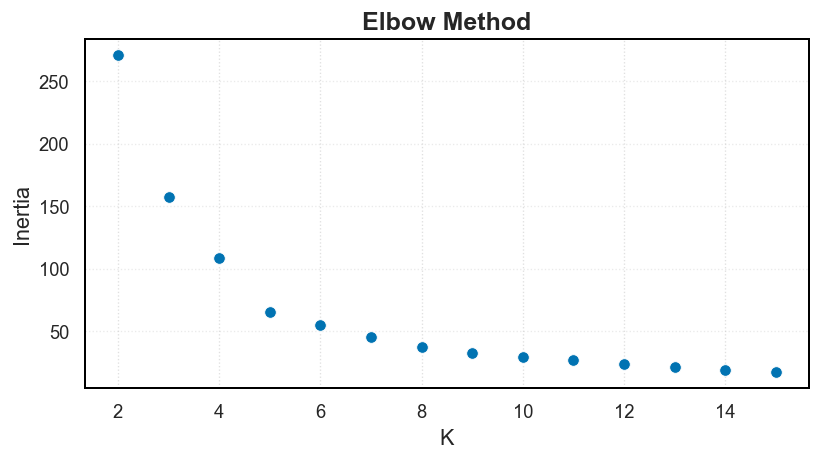

In [16]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4))

sns.scatterplot(
    x=range(2, k_max + 1),
    y=inertia,
    ax=axes,
)

axes.grid(axis="y", linestyle=":", alpha=0.4)
axes.set_title("Elbow Method")
axes.set_xlabel("K")
axes.set_ylabel("Inertia")

plt.tight_layout()
plt.show()

Observation :
- Le coude semble être aux alentours de K = 5.

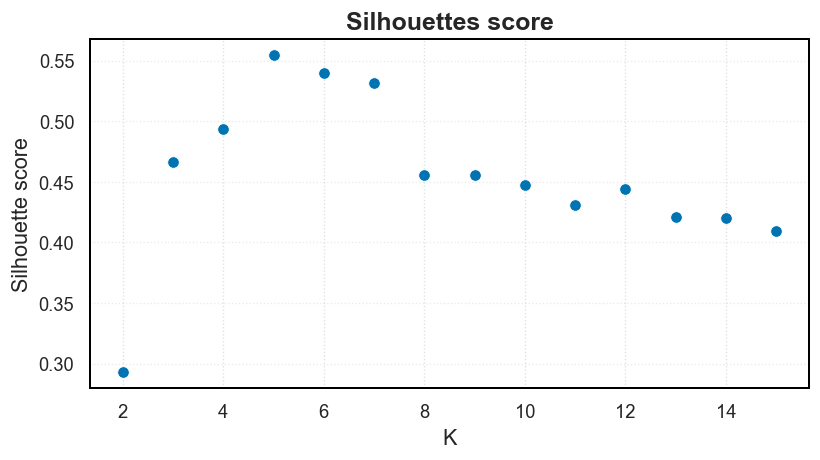

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(7, 4))

sns.scatterplot(
    x=range(2, k_max + 1),
    y=silhouettes,
    ax=axes,
)

axes.grid(axis="y", linestyle=":", alpha=0.4)
axes.set_title("Silhouettes score")
axes.set_xlabel("K")
axes.set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

In [18]:
K_optimal = 2 + np.argmax(silhouettes)

print(
    f"Le score de silhouette est maximale pour K = {K_optimal} :"
    f" {max(silhouettes):.4f}"
)

Le score de silhouette est maximale pour K = 5 : 0.5547


## Clustering avec K-Means

In [19]:
kmeans_optimal = KMeans(n_clusters=K_optimal, random_state=SEED, n_init=10)

y_pred_optimal = kmeans_optimal.fit_predict(X_transformed)

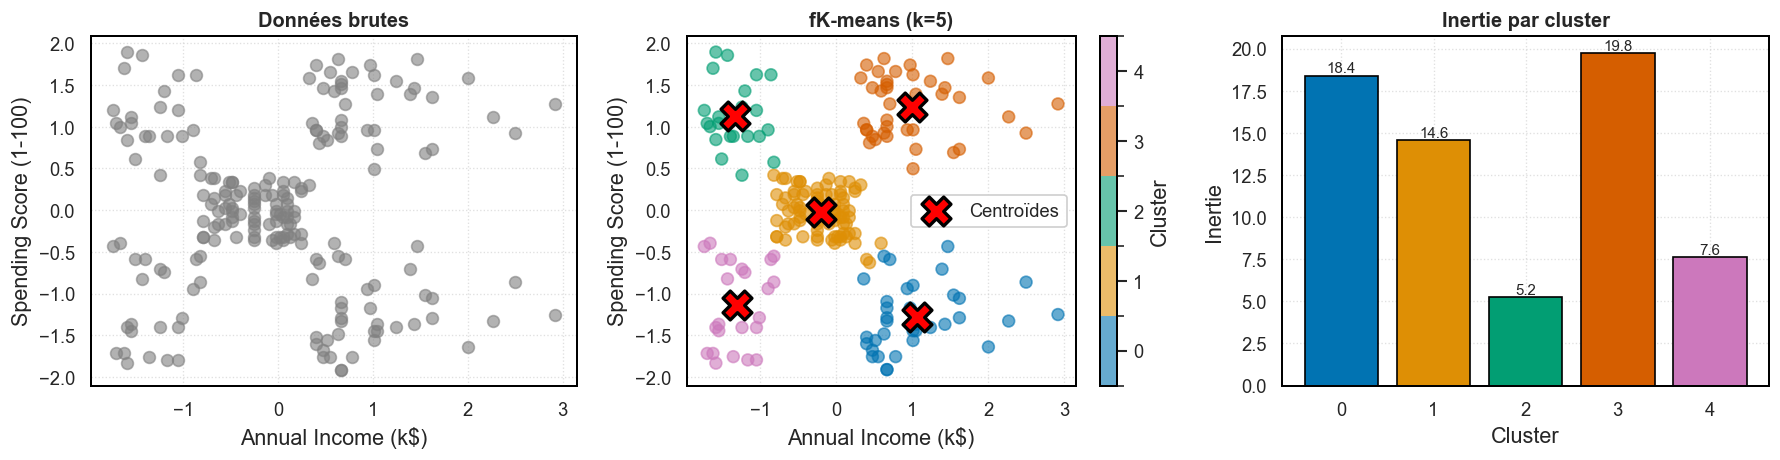

Inertie totale: 65.57


In [20]:
cluster_cmap = ListedColormap(
    sns.color_palette(
        "colorblind",
        n_colors=K_optimal
    )
)
bounds = np.arange(-0.5, K_optimal + 0.5, 1)
cluster_norm = BoundaryNorm(bounds, cluster_cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Données brutes
axes[0].scatter(X_transformed[:, 0], X_transformed[:, 1], c="gray", alpha=0.6, s=50)
axes[0].set_title("Données brutes", fontsize=12, fontweight="bold")
axes[0].set_xlabel(feature1)
axes[0].set_ylabel(feature2)

# Clusters prédits
scatter = axes[1].scatter(
    X_transformed[:, 0],
    X_transformed[:, 1],
    c=y_pred_optimal,
    cmap=cluster_cmap,
    norm=cluster_norm,
    alpha=0.6,
    s=50,
)
axes[1].scatter(
    kmeans_optimal.cluster_centers_[:, 0],
    kmeans_optimal.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=2,
    label="Centroïdes",
)
axes[1].set_title(f"fK-means (k={K_optimal})", fontsize=12, fontweight="bold")
axes[1].set_xlabel(feature1)
axes[1].set_ylabel(feature2)
axes[1].legend()
cbar = plt.colorbar(
    scatter,
    ax=axes[1],
    ticks=range(K_optimal)
)
cbar.set_label("Cluster")
cbar.set_ticks(range(K_optimal))
cbar.set_ticklabels(range(K_optimal))

# Inertie par cluster
inertia_by_cluster = []
for i in range(K_optimal):
    cluster_points = X_transformed[y_pred_optimal == i]
    center = kmeans_optimal.cluster_centers_[i]
    inertia = np.sum((cluster_points - center) ** 2)
    inertia_by_cluster.append(inertia)

axes[2].bar(
    range(K_optimal),
    inertia_by_cluster,
    color=COLORBLIND_PALETTE,
    edgecolor="black",
)
axes[2].set_title("Inertie par cluster", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Inertie")
axes[2].set_xticks(range(K_optimal))

for i, inertia in enumerate(inertia_by_cluster):
    axes[2].text(
        i,
        inertia,
        f"{inertia:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print(f"Inertie totale: {sum(inertia_by_cluster):.2f}")

Observations :
- Les clusters apparaissent globalement compacts et de forme quasi convexe, ce qui est cohérent avec les hypothèses de K-Means.
- Les clusters présentent des effectifs relativement équilibrés.
- Les centroïdes sont relativement bien espacés les uns des autres, ce qui suggère une bonne séparation entre les segments. Les clusters semblent donc présenter des profils clients suffisamment distincts pour être interprétables.
- Les observations sont globalement regroupées autour de leur centroïde, avec toutefois des niveaux de dispersion différents selon les clusters traduisant l'hétérogénéité des profils client.
- Pertinence du nombre de clusters : la répartition observée avec 5 clusters semble cohérente visuellement.

## Analyse métier des segments

In [21]:
stats_cluster = {
    "index": [],
    "count": [],
    "nb_female": [],
    "nb_male": [],
    "avg_age": [],
    "std_age": [],
    "avg_annual_income": [],
    "std_annual_income": [],
    "avg_spending_score": [],
    "std_spending_score": [],
}

for i in range(K_optimal):
    X_cluster = df[y_pred_optimal == i]

    stats_cluster["index"].append(i)
    stats_cluster["count"].append(len(X_cluster))
    stats_cluster["nb_female"].append(len(X_cluster[X_cluster["Genre"] == "Female"]))
    stats_cluster["nb_male"].append(len(X_cluster[X_cluster["Genre"] == "Male"]))
    stats_cluster["avg_age"].append(X_cluster["Age"].mean())
    stats_cluster["std_age"].append(X_cluster["Age"].std())
    stats_cluster["avg_annual_income"].append(X_cluster["Annual Income (k$)"].mean())
    stats_cluster["std_annual_income"].append(X_cluster["Annual Income (k$)"].std())
    stats_cluster["avg_spending_score"].append(
        X_cluster["Spending Score (1-100)"].mean()
    )
    stats_cluster["std_spending_score"].append(
        X_cluster["Spending Score (1-100)"].std()
    )

stats_cluster_df = pd.DataFrame(stats_cluster)
stats_cluster_df.head()

,index,count,nb_female,nb_male,avg_age,std_age,avg_annual_income,std_annual_income,avg_spending_score,std_spending_score
0,0,35,16,19,41.114286,11.341676,88.200000,16.399067,17.114286,9.952154
1,1,81,48,33,42.716049,16.447822,55.296296,8.988109,49.518519,6.530909
2,2,22,13,9,25.272727,5.257030,25.727273,7.566731,79.363636,10.504174
3,3,39,21,18,32.692308,3.728650,86.538462,16.312485,82.128205,9.364489
4,4,23,14,9,45.217391,13.228607,26.304348,7.893811,20.913043,13.017167


Observations :
- Cluster 0 – Occasionnels : clients d'environ 41 ans, disposant d'un revenu annuel élevé (88 k$ en moyenne), mais présentant un score de dépense faible (17). Ils disposent d'un pouvoir d'achat important, mais dépensent relativement peu.
- Cluster 1 – Cibles : clients d'environ 43 ans, avec un revenu annuel intermédiaire (55 k$) et un score de dépense moyen (50). Ce profil représente une clientèle équilibrée, constituant une cible potentielle pour des actions marketing.
- Cluster 2 – Impulsifs : clients jeunes, d'environ 25 ans, avec un revenu annuel faible (25 k$), mais un score de dépense élevé (79). Malgré des revenus limités, ils présentent une forte propension à la dépense.
- Cluster 3 – VIP : clients d'environ 32 ans, bénéficiant d'un revenu annuel élevé (87 k$) et affichant également un score de dépense élevé (82). Ils représentent le segment le plus attractif en termes de valeur client potentielle.
- Cluster 4 – Économes : clients d'environ 45 ans, avec un revenu annuel faible (26 k$) et un score de dépense faible (21). Leur niveau de revenu et leur comportement de dépense sont tous deux relativement faibles.